In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from dataclasses import dataclass, field
import pandas as pd

In [67]:
def generate_logistic_regression_data(n_samples=500, random_state=42):
    """
    Tạo dữ liệu giả lập cho bài toán Logistic Regression.
    Trả về:
        X (numpy array): Ma trận features (n_samples, 2).
        y (numpy array): Vector labels (n_samples,), chứa các giá trị 0 và 1.
    """
    X, y = make_classification(
        n_samples=n_samples,
        n_features=2,           # 2 features để dễ dàng vẽ đồ thị 2D
        n_redundant=0,          # Không có feature thừa
        n_informative=2,        # Cả 2 feature đều mang thông tin phân loại
        n_clusters_per_class=1, # Mỗi class là một cụm duy nhất
        flip_y=0.05,            # Thêm 5% nhiễu (đảo nhãn) để model khó phân loại hoàn hảo hơn
        class_sep=2.0,          # Khoảng cách giữa 2 class (càng lớn càng dễ tách)
        random_state=random_state
    )
    return X, y

def plot_logistic_data(X, y):
    """
    Hàm hỗ trợ trực quan hóa dữ liệu trong Jupyter Notebook.
    """
    plt.figure(figsize=(8, 6))
    
    # Vẽ các điểm thuộc Class 0
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], 
                color='royalblue', label='Class 0', alpha=0.8, edgecolors='k')
    
    # Vẽ các điểm thuộc Class 1
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], 
                color='crimson', label='Class 1', alpha=0.8, edgecolors='k')
    
    plt.title("Dữ liệu giả lập cho phân loại nhị phân")
    plt.xlabel("Feature 1 ($x_1$)")
    plt.ylabel("Feature 2 ($x_2$)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

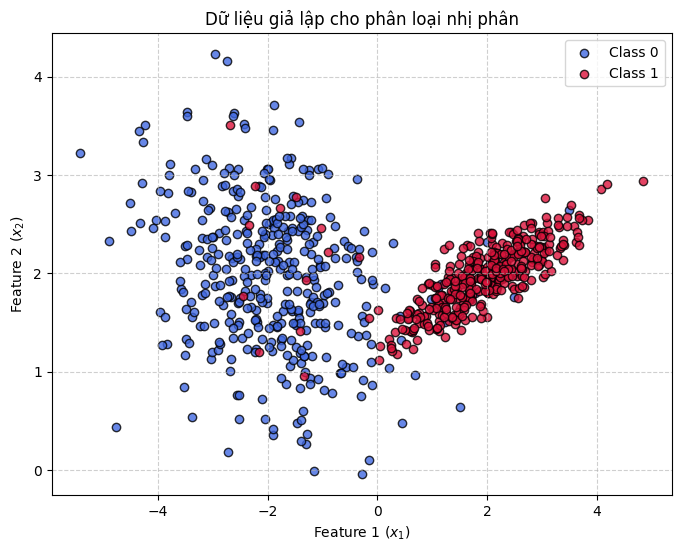

Kích thước tập X: (800, 2)
Kích thước tập y: (800,)


In [68]:
X, y = generate_logistic_regression_data(n_samples=800)
plot_logistic_data(X, y)

# In thử kích thước dữ liệu để xác nhận
print(f"Kích thước tập X: {X.shape}")
print(f"Kích thước tập y: {y.shape}")

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

@dataclass
class LogisticRegression:
    data: np.ndarray
    targets: np.ndarray
    learning_rate: float = 0.01
    n_iter: int = 1000
    epsilon: float = 1e-4 
    random_state: int = None
    n_check: int = 20
    rd: np.random.Generator = field(init=False)
    w: list = field(init=False, default_factory=list)

    def __post_init__(self):
        self.rd = np.random.default_rng(self.random_state)
        N = self.data.shape[0]
        self.data = np.concatenate((np.ones((N, 1)), self.data), axis=1)
        w_init = self.rd.normal(size=self.data.shape[1])
        self.w.append(w_init)
        
    def _grad(self, w_i, x_i, y_i):
        z = np.dot(w_i, x_i)
        sigmoid = 1 / (1 + np.exp(-z))
        grad = (sigmoid - y_i) * x_i
        return grad

    def train(self):
        N = self.data.shape[0]
        
        for it in range(self.n_iter):
            indices = self.rd.permutation(N)
            
            for actual_index, i in enumerate(indices):
                x_i = self.data[i]
                y_i = self.targets[i]
                w_i = self.w[-1]
                g = self._grad(w_i, x_i, y_i)
                w_new = w_i - self.learning_rate * g
                self.w.append(w_new)
                if len(self.w) > self.n_check and actual_index % self.n_check == 0:
                    w_diff = np.linalg.norm(w_new - self.w[-self.n_check])
                    if w_diff < self.epsilon:
                        print(f"Hội tụ tại epoch {it+1}, bước {actual_index}")
                        return self.w
                        
        print(f"Thuật toán kết thúc sau {self.n_iter} epochs (chưa đạt epsilon tối đa).")
        return self.w
    
    def plot(self):
        """
        Vẽ đồ thị phân tán và đường ranh giới quyết định (Decision Boundary).
        Hàm này giả định dữ liệu ban đầu có 2 features (2 chiều không gian).
        """
        # Kiểm tra xem dữ liệu có đúng 3 chiều (1 cột bias + 2 features) hay không
        if self.data.shape[1] != 3:
            print("Hàm plot hiện tại chỉ hỗ trợ biểu diễn dữ liệu 2 chiều (2 features).")
            return
            
        plt.figure(figsize=(8, 6))
        
        # Trích xuất dữ liệu gốc (bỏ cột bias)
        X_plot = self.data[:, 1:]
        
        # Vẽ các điểm dữ liệu phân tách theo nhãn
        plt.scatter(X_plot[self.targets == 0][:, 0], X_plot[self.targets == 0][:, 1], 
                    color='royalblue', label='Class 0', alpha=0.7, edgecolors='k')
        plt.scatter(X_plot[self.targets == 1][:, 0], X_plot[self.targets == 1][:, 1], 
                    color='crimson', label='Class 1', alpha=0.7, edgecolors='k')
        
        # Vẽ ranh giới quyết định: w_0 + w_1*x_1 + w_2*x_2 = 0
        w_final = self.w[-1]
        
        x1_min, x1_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
        x1_vals = np.array([x1_min, x1_max])
        
        # Tránh lỗi chia cho 0 nếu trọng số w_2 quá nhỏ
        if np.abs(w_final[2]) > 1e-7:
            x2_vals = -(w_final[0] + w_final[1] * x1_vals) / w_final[2]
            plt.plot(x1_vals, x2_vals, color='black', linestyle='--', linewidth=2, label='Decision Boundary')
        
        plt.title("Decision Boundary - Logistic Regression")
        plt.xlabel("Feature 1 ($x_1$)")
        plt.ylabel("Feature 2 ($x_2$)")
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()
        
    def plot_3d_probability(self):
        """
        Vẽ đồ thị 3D biểu diễn bề mặt xác suất của Logistic Regression.
        """
        if self.data.shape[1] != 3:
            print("Hàm này chỉ hỗ trợ biểu diễn dữ liệu có 2 features.")
            return

        # Khởi tạo figure 3D
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        X_plot = self.data[:, 1:]
        w_final = self.w[-1]
        
        # 1. Tạo lưới tọa độ (meshgrid) cho mặt phẳng 2 features
        x1_min, x1_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
        x2_min, x2_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
        
        xx1, xx2 = np.meshgrid(
            np.linspace(x1_min, x1_max, 50),
            np.linspace(x2_min, x2_max, 50)
        )
        
        # 2. Tính giá trị xác suất Z cho từng điểm trên lưới
        # z_linear = w_0 + w_1*x_1 + w_2*x_2
        z_linear = w_final[0] + w_final[1]*xx1 + w_final[2]*xx2
        # Giới hạn giá trị để tránh cảnh báo tràn số của exp
        z_linear = np.clip(z_linear, -250, 250)
        probability_surface = 1 / (1 + np.exp(-z_linear))
        
        # 3. Vẽ bề mặt xác suất (Sigmoid surface)
        surf = ax.plot_surface(xx1, xx2, probability_surface, 
                               cmap='viridis', alpha=0.7, edgecolor='none')
        
        # 4. Vẽ mặt phẳng cắt tại Z = 0.5 (Ngưỡng phân loại)
        ax.plot_surface(xx1, xx2, np.full_like(probability_surface, 0.5), 
                        color='gray', alpha=0.3)
        
        # 5. Đưa các điểm dữ liệu gốc vào không gian 3D
        # Class 0 nằm ở mặt Z = 0
        ax.scatter(X_plot[self.targets == 0][:, 0], X_plot[self.targets == 0][:, 1], 
                   np.zeros((self.targets == 0).sum()), 
                   color='royalblue', label='Class 0', edgecolors='k', s=40)
        
        # Class 1 nằm ở mặt Z = 1
        ax.scatter(X_plot[self.targets == 1][:, 0], X_plot[self.targets == 1][:, 1], 
                   np.ones((self.targets == 1).sum()), 
                   color='crimson', label='Class 1', edgecolors='k', s=40)
        
        ax.set_title("Không gian xác suất 3D - Logistic Regression")
        ax.set_xlabel("Feature 1 ($x_1$)")
        ax.set_ylabel("Feature 2 ($x_2$)")
        ax.set_zlabel("Xác suất $\hat{y}$")
        ax.legend()
        plt.show()

<>:144: SyntaxWarning: invalid escape sequence '\h'
<>:144: SyntaxWarning: invalid escape sequence '\h'
C:\Users\NHUT PHAT\AppData\Local\Temp\ipykernel_8976\4256161925.py:144: SyntaxWarning: invalid escape sequence '\h'
  ax.set_zlabel("Xác suất $\hat{y}$")


Thuật toán kết thúc sau 500 epochs (chưa đạt epsilon tối đa).


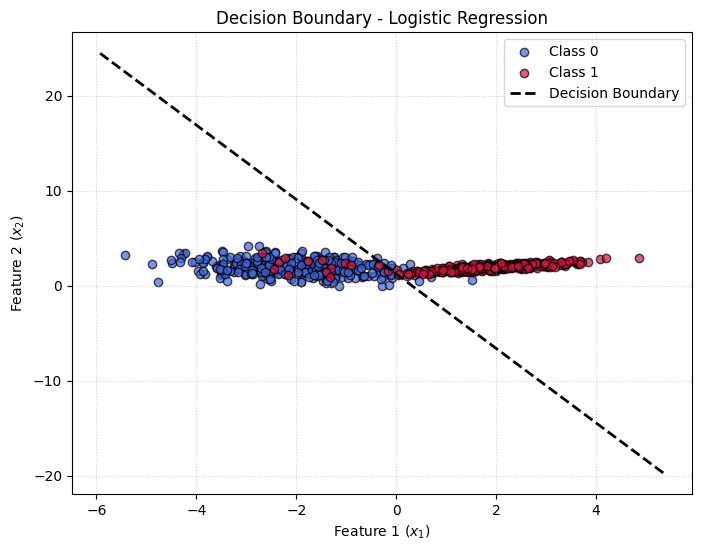

In [70]:
model = LogisticRegression(data=X, targets=y, learning_rate=0.05, n_iter=500, random_state=42)
model.train()
model.plot()

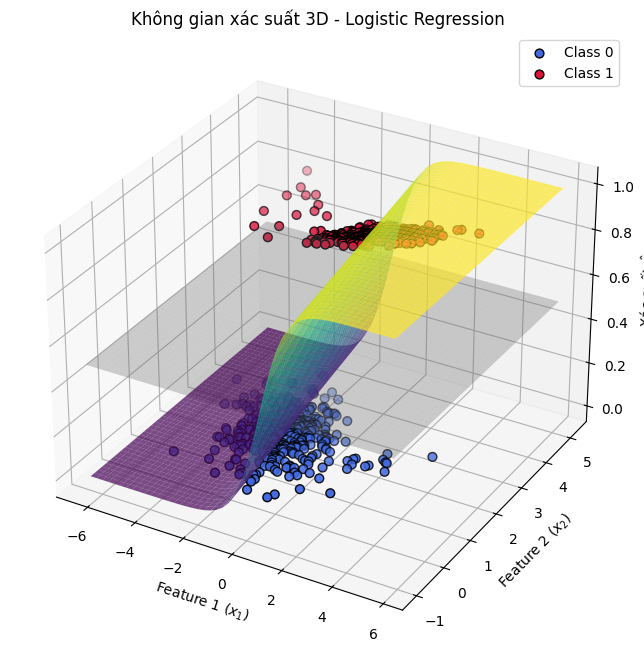

In [71]:
model.plot_3d_probability()